Dataset Preview
  Month       Channel  Visitors  Leads  Qualified_Leads  Customers  Revenue  \
0   Jan  Facebook Ads     15000   3200             1800        450    90000   
1   Jan    Google Ads     18000   4000             2200        600   120000   
2   Jan     Instagram     12000   2500             1400        320    65000   
3   Jan      LinkedIn      8000   1800             1200        350    85000   
4   Feb  Facebook Ads     16000   3400             1900        500   100000   

   Marketing_Spend  
0            25000  
1            30000  
2            18000  
3            15000  
4            26000  

Conversion Metrics
         Channel  Lead_Conversion_%  Customer_Conversion_%
0   Facebook Ads              21.33                   3.00
1     Google Ads              22.22                   3.33
2      Instagram              20.83                   2.67
3       LinkedIn              22.50                   4.38
4   Facebook Ads              21.25                   3.12
5     Goo

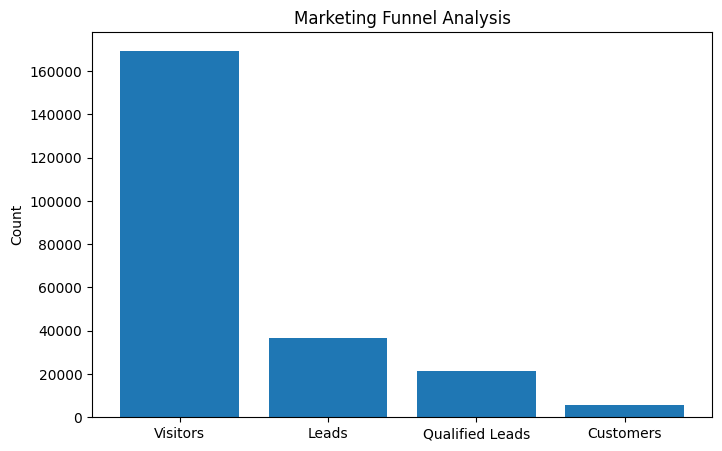

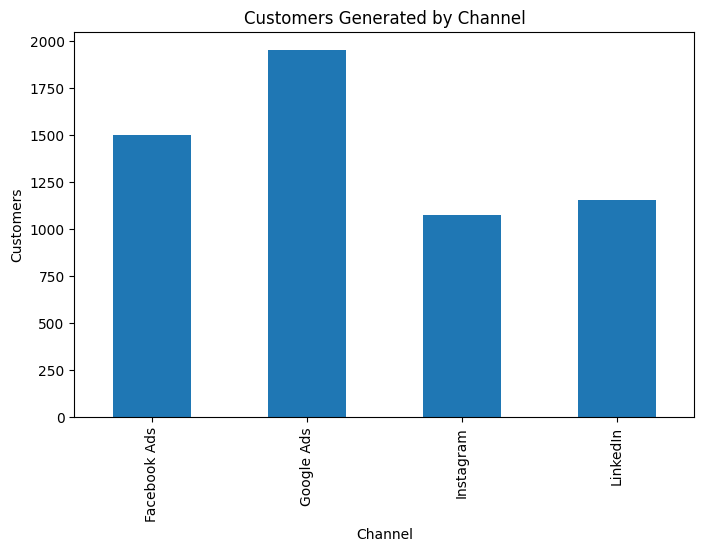

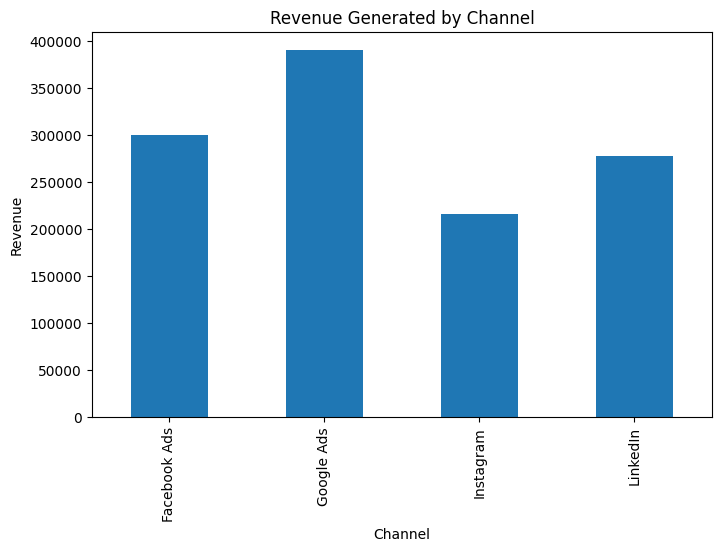


ROI Analysis
         Channel   ROI_%
0   Facebook Ads  260.00
1     Google Ads  300.00
2      Instagram  261.11
3       LinkedIn  466.67
4   Facebook Ads  284.62
5     Google Ads  306.25
6      Instagram  268.42
7       LinkedIn  475.00
8   Facebook Ads  307.41
9     Google Ads  324.24
10     Instagram  300.00
11      LinkedIn  488.24

Best Performing Channel: Google Ads


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("/content/marketing_funnel.csv")

print("Dataset Preview")
print(df.head())

# Conversion Metrics
df["Lead_Conversion_%"] = round((df["Leads"] / df["Visitors"]) * 100, 2)
df["Customer_Conversion_%"] = round((df["Customers"] / df["Visitors"]) * 100, 2)

print("\nConversion Metrics")
print(df[["Channel","Lead_Conversion_%","Customer_Conversion_%"]])

# Total Funnel Analysis
total_visitors = df["Visitors"].sum()
total_leads = df["Leads"].sum()
total_qualified = df["Qualified_Leads"].sum()
total_customers = df["Customers"].sum()

stages = ["Visitors","Leads","Qualified Leads","Customers"]
values = [total_visitors,total_leads,total_qualified,total_customers]

plt.figure(figsize=(8,5))
plt.bar(stages, values)
plt.title("Marketing Funnel Analysis")
plt.ylabel("Count")
plt.show()

# Channel Performance
channel_data = df.groupby("Channel")["Customers"].sum()

plt.figure(figsize=(8,5))
channel_data.plot(kind="bar")
plt.title("Customers Generated by Channel")
plt.ylabel("Customers")
plt.show()

# Revenue by Channel
revenue = df.groupby("Channel")["Revenue"].sum()

plt.figure(figsize=(8,5))
revenue.plot(kind="bar")
plt.title("Revenue Generated by Channel")
plt.ylabel("Revenue")
plt.show()

# ROI Calculation
df["ROI_%"] = round(
    ((df["Revenue"] - df["Marketing_Spend"])
     / df["Marketing_Spend"]) * 100,2
)

print("\nROI Analysis")
print(df[["Channel","ROI_%"]])

best_channel = df.groupby("Channel")["Customers"].sum().idxmax()

print("\nBest Performing Channel:", best_channel)

In [4]:
visitor_to_lead = ((total_visitors-total_leads)/total_visitors)*100
lead_to_qualified = ((total_leads-total_qualified)/total_leads)*100
qualified_to_customer = ((total_qualified-total_customers)/total_qualified)*100

print("Visitor → Lead Drop-Off:", round(visitor_to_lead,2),"%")
print("Lead → Qualified Lead Drop-Off:", round(lead_to_qualified,2),"%")
print("Qualified Lead → Customer Drop-Off:", round(qualified_to_customer,2),"%")

Visitor → Lead Drop-Off: 78.29 %
Lead → Qualified Lead Drop-Off: 41.85 %
Qualified Lead → Customer Drop-Off: 73.5 %
